<a href="https://colab.research.google.com/github/prath2131/Electricity-ML-project/blob/main/Assignment_2_Electricity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

Load Data

In [2]:
df= pd.read_csv("load_data.csv")
df.head()

,Date_Time,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Load_Type
0,01-01-2018 00:15,8.753692,2.95,0.0,0.0,73.210000,100.0,900.000000,Light_Load
1,01-01-2018 00:30,4.000000,4.46,0.0,0.0,66.770000,100.0,1800.000000,Light_Load
2,01-01-2018 00:45,3.240000,3.28,0.0,0.0,70.280000,100.0,8070.880991,Light_Load
3,01-01-2018 01:00,3.310000,3.56,0.0,0.0,68.090000,100.0,3600.000000,Light_Load
4,01-01-2018 01:15,3.820000,4.50,0.0,0.0,133.655666,NaN,4500.000000,Light_Load


Electricity consumption units; target variable is Load_Type.


---



Data Cleaning, where missing rows removed

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35041 entries, 0 to 35040
Data columns (total 9 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Date_Time                             35041 non-null  object 
 1   Usage_kWh                             33482 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  34165 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  33885 non-null  float64
 4   CO2(tCO2)                             34586 non-null  float64
 5   Lagging_Current_Power_Factor          34691 non-null  float64
 6   Leading_Current_Power_Factor          33570 non-null  float64
 7   NSM                                   34586 non-null  float64
 8   Load_Type                             35041 non-null  object 
dtypes: float64(7), object(2)
memory usage: 2.4+ MB


In [4]:
df.isnull().sum()

,0
Date_Time,0
Usage_kWh,1559
Lagging_Current_Reactive.Power_kVarh,876
Leading_Current_Reactive_Power_kVarh,1156
CO2(tCO2),455
Lagging_Current_Power_Factor,350
Leading_Current_Power_Factor,1471
NSM,455
Load_Type,0


In [5]:
print("Before:", len(df))

df = df.dropna()

print("After:", len(df))
df = df.copy()

Before: 35041
After: 29178


Exploratory Data Analysis (EDA)

In [6]:
df["Load_Type"].value_counts()

,count
Load_Type,
Light_Load,15035
Medium_Load,8078
Maximum_Load,6065


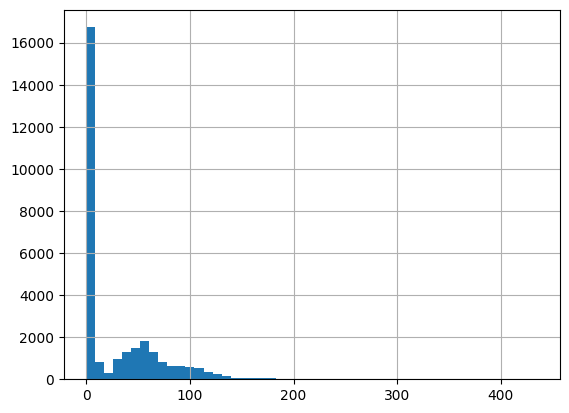

In [7]:
df["Usage_kWh"].hist(bins=50)
plt.show()

Usage_kWh plot is right skewed

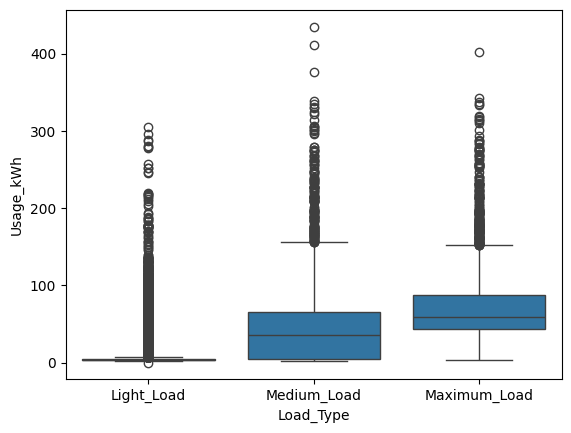

In [8]:
sns.boxplot(x="Load_Type", y="Usage_kWh", data=df)
plt.show()

Usage_kWh increases across load categories, so important feature

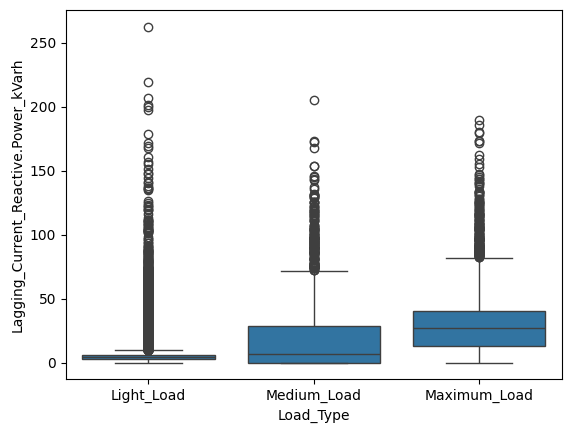

In [9]:
sns.boxplot( x="Load_Type", y="Lagging_Current_Reactive.Power_kVarh", data=df)
plt.show()

Usage_kWh and Lagging Current Reactive Power strongly related to Load_Type


Date and time Extraction  
The Date_Time column was converted into date and time format.  
Features were extracted as Hour, Weekday, Month, Day

In [12]:
df["Date_Time"]= pd.to_datetime(df["Date_Time"],  format="%d-%m-%Y %H:%M")
df["Hour"]= df["Date_Time"].dt.hour
df["Weekday"] = df["Date_Time"].dt.dayofweek
df["Month"]= df["Date_Time"].dt.month
df["Day"] = df["Date_Time"].dt.day

In [13]:
df[["Date_Time", "Hour"]].head()

,Date_Time,Hour
0,2018-01-01 00:15:00,0
1,2018-01-01 00:30:00,0
2,2018-01-01 00:45:00,0
3,2018-01-01 01:00:00,1
5,2018-01-01 01:30:00,1


In [15]:
df["Weekday"].value_counts().sort_index()

,count
Weekday,
0,4251
1,4136
2,4211
3,4148
4,4130
5,4118
6,4184


In [16]:
df["Hour"].value_counts().sort_index()


,count
Hour,
0,1187
1,1222
2,1208
3,1220
4,1216
5,1213
6,1213
7,1231
8,1226


In [17]:
df["Month"].value_counts().sort_index()

,count
Month,
1,2478
2,2243
3,2482
4,2374
5,2502
6,2386
7,2484
8,2499
9,2401


Encoding target value

In [18]:
le= LabelEncoder()
df["Load_Type"]= le.fit_transform(df["Load_Type"])
df["Load_Type"].unique()

array([0, 2, 1])

Train-test data split by month  
last month test data and remaining training data

In [19]:
train_df = df[df["Month"] < 12]
test_df = df[df["Month"] == 12]

In [20]:
x_train = train_df.drop(columns=["Load_Type", "Date_Time"])
y_train = train_df["Load_Type"]

x_test = test_df.drop(columns=["Load_Type", "Date_Time"])
y_test = test_df["Load_Type"]

print(train_df["Month"].unique())
print(test_df["Month"].unique())

[ 1  2  3  4  5  6  7  8  9 10 11]
[12]


In [21]:
x_train.columns

Index(['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'Hour', 'Weekday', 'Month', 'Day'],
      dtype='object')

# Model 1 Decision Tree

Train model

In [25]:
dt= DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.9008163265306123
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      1428
           1       0.87      0.94      0.90       438
           2       0.77      0.99      0.87       584

    accuracy                           0.90      2450
   macro avg       0.88      0.93      0.90      2450
weighted avg       0.92      0.90      0.90      2450



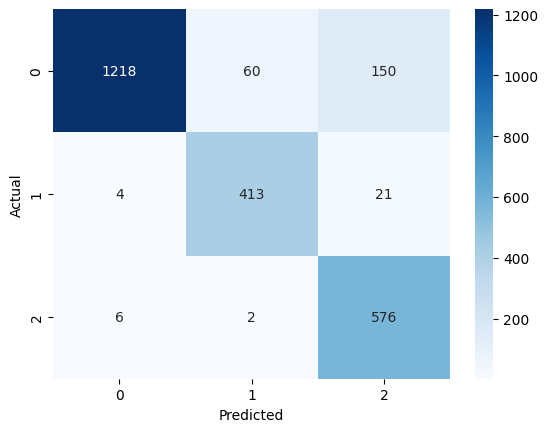

In [29]:
cm_dt= confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree model accuracy 90%

In [31]:
importance= pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": dt.feature_importances_}
)
importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
7,Hour,0.480377
6,NSM,0.158488
0,Usage_kWh,0.137598
9,Month,0.119239
8,Weekday,0.042068
10,Day,0.033850
2,Leading_Current_Reactive_Power_kVarh,0.012063
5,Leading_Current_Power_Factor,0.007033
1,Lagging_Current_Reactive.Power_kVarh,0.005615
4,Lagging_Current_Power_Factor,0.003008


# Model 2 Random Forest

In [33]:
rf= RandomForestClassifier(
     n_estimators=100,
    random_state=42
)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9326530612244898
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      1428
           1       0.92      0.92      0.92       438
           2       0.83      0.98      0.90       584

    accuracy                           0.93      2450
   macro avg       0.91      0.94      0.92      2450
weighted avg       0.94      0.93      0.93      2450



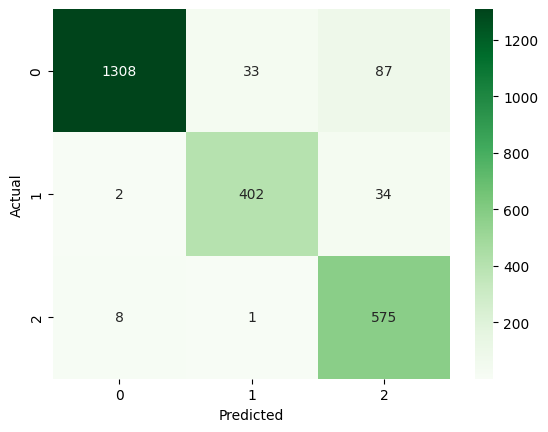

In [34]:
cmr= confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cmr,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
importance_rf = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
})

importance_rf.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
7,Hour,0.279645
6,NSM,0.239309
0,Usage_kWh,0.124745
9,Month,0.104999
3,CO2(tCO2),0.064636
8,Weekday,0.038065
4,Lagging_Current_Power_Factor,0.036175
1,Lagging_Current_Reactive.Power_kVarh,0.032090
5,Leading_Current_Power_Factor,0.028958
2,Leading_Current_Reactive_Power_kVarh,0.026857


feature of highest importance is time of day in Hour and NSM

Model Comparison  


In [38]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [0.90, 0.933],
    "F1 Score": [0.90, 0.93],
})

comparison

,Model,Accuracy,F1 Score
0,Decision Tree,0.900,0.90
1,Random Forest,0.933,0.93
